<a href="https://colab.research.google.com/github/akulvibhore/flyrank-ml-internship-/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/akulvibhore/flyrank-ml-internship-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
### Research question

Can historical search-performance and engagement signals identify content that is likely to experience weaker performance in the following observation window?

### Decision supported

The analysis is intended to support prioritization of content for human review. The output is a ranked decision-support list, not a prediction of Google's ranking algorithm or a guarantee of future performance.


In [3]:
# ============================================================
# CAPSTONE — RESET DATA CONNECTION
# ============================================================

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

HF_TOKEN = userdata.get("HFTOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HFTOKEN is not available in Colab Secrets."
    )

print("HF token loaded:", True)

# Create a fresh DuckDB connection
con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

# Define warehouse path
FULL_DAILY_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/**/*.parquet"
)

print("DuckDB connection ready.")
print("Warehouse path:")
print(FULL_DAILY_PATH)

HF token loaded: True
DuckDB connection ready.
Warehouse path:
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet


In [4]:
# ============================================================
# TEST WAREHOUSE
# ============================================================

test_query = f"""
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date

FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)
"""

test_result = con.sql(test_query).df()

display(test_result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,min_date,max_date
0,78835655,2025-01-27,2026-06-30


In [5]:
# ============================================================
# CREATE FUTURE TARGET
# ============================================================

TARGET_START = "2026-06-01"
TARGET_END = "2026-06-30"

target_query = f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(
        COALESCE(gsc_impressions, 0)
    ) AS target_impressions,

    SUM(
        COALESCE(gsc_clicks, 0)
    ) AS target_clicks,

    SUM(
        COALESCE(ga4_sessions, 0)
    ) AS target_sessions

FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)

WHERE report_date BETWEEN
    DATE '{TARGET_START}'
    AND DATE '{TARGET_END}'

GROUP BY
    client_hash_id,
    content_hash_id

HAVING
    SUM(
        COALESCE(gsc_impressions, 0)
    ) >= 100
"""

target = con.sql(target_query).df()

# Calculate future CTR
target["target_ctr"] = np.where(
    target["target_impressions"] > 0,
    target["target_clicks"] /
    target["target_impressions"],
    0
)

print("Target dataset:", target.shape)

display(target.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Target dataset: (101917, 6)


,client_hash_id,content_hash_id,target_impressions,target_clicks,target_sessions,target_ctr
0,client_e547b89c05043229,content_c51fb84dfa6c3e30,147.0,0.0,0.0,0.000000
1,client_e547b89c05043229,content_5da6dbcc97ab64a4,1372.0,3.0,5.0,0.002187
2,client_e547b89c05043229,content_e44bcafddb970d2a,301.0,0.0,1.0,0.000000
3,client_e547b89c05043229,content_f036da55d4d22edf,198.0,0.0,1.0,0.000000
4,client_e547b89c05043229,content_96d2df123457b9c0,136.0,0.0,0.0,0.000000


In [14]:
print(con.sql(f"""
DESCRIBE SELECT *
FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)
""").df().to_string(index=False))

             column_name column_type null  key default extra
             report_date        DATE  YES None    None  None
          client_hash_id     VARCHAR  YES None    None  None
         content_hash_id     VARCHAR  YES None    None  None
          client_has_gsc     BOOLEAN  YES None    None  None
          client_has_ga4     BOOLEAN  YES None    None  None
      gsc_data_available     BOOLEAN  YES None    None  None
      ga4_data_available     BOOLEAN  YES None    None  None
         gsc_impressions      BIGINT  YES None    None  None
              gsc_clicks      BIGINT  YES None    None  None
        gsc_sum_position      BIGINT  YES None    None  None
        gsc_avg_position      DOUBLE  YES None    None  None
           ga4_pageviews      BIGINT  YES None    None  None
            ga4_sessions      BIGINT  YES None    None  None
               ga4_users      BIGINT  YES None    None  None
    ga4_engaged_sessions      BIGINT  YES None    None  None
ga4_total_engagement_sec

In [15]:
print(con.sql(f"""
SELECT *
FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)
LIMIT 2
""").df().columns.tolist())

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


In [16]:
# ==============================
# BUILD HISTORICAL FEATURES
# ==============================

FEATURE_START = "2026-03-03"
FEATURE_END = "2026-05-31"

feature_query = f"""
SELECT
    client_hash_id,
    content_hash_id,

    -- Google Search Console
    SUM(COALESCE(gsc_impressions, 0)) AS impressions_90d,
    SUM(COALESCE(gsc_clicks, 0)) AS clicks_90d,

    -- Google Analytics
    SUM(COALESCE(ga4_sessions, 0)) AS sessions_90d,
    SUM(COALESCE(ga4_engaged_sessions, 0)) AS engaged_sessions_90d,

    -- Traffic sources
    SUM(COALESCE(sessions_organic, 0)) AS organic_sessions_90d,
    SUM(COALESCE(sessions_ai, 0)) AS ai_sessions_90d,

    -- Engagement
    SUM(COALESCE(scroll_events, 0)) AS scroll_events_90d,

    -- Recent 30 days
    SUM(
        CASE
            WHEN report_date >= DATE '2026-05-02'
            THEN COALESCE(gsc_impressions, 0)
            ELSE 0
        END
    ) AS recent_30d_impressions,

    -- Previous 30 days
    SUM(
        CASE
            WHEN report_date < DATE '2026-05-02'
            THEN COALESCE(gsc_impressions, 0)
            ELSE 0
        END
    ) AS previous_30d_impressions,

    -- Average Google position
    AVG(gsc_avg_position) AS avg_position_90d,

    -- Historical CTR
    CASE
        WHEN SUM(COALESCE(gsc_impressions, 0)) > 0
        THEN
            SUM(COALESCE(gsc_clicks, 0))
            / SUM(COALESCE(gsc_impressions, 0))
        ELSE 0
    END AS ctr_90d

FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)

WHERE report_date BETWEEN DATE '{FEATURE_START}'
                      AND DATE '{FEATURE_END}'

GROUP BY
    client_hash_id,
    content_hash_id

HAVING SUM(COALESCE(gsc_impressions, 0)) >= 100
"""

features = con.sql(feature_query).df()

# Calculate impression change
features["impression_change_pct"] = np.where(
    features["previous_30d_impressions"] > 0,
    (
        features["recent_30d_impressions"]
        - features["previous_30d_impressions"]
    ) / features["previous_30d_impressions"],
    0
)

print("Features created successfully!")
print("Shape:", features.shape)

display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Features created successfully!
Shape: (150000, 14)


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,engaged_sessions_90d,organic_sessions_90d,ai_sessions_90d,scroll_events_90d,recent_30d_impressions,previous_30d_impressions,avg_position_90d,ctr_90d,impression_change_pct
0,client_3ffa76342f366962,content_8e176a2297c48984,103.0,1.0,1.0,0.0,1.0,0.0,0.0,19.0,84.0,5.642560,0.009709,-0.773810
1,client_3ffa76342f366962,content_5bc7733a87eb933b,141.0,2.0,3.0,0.0,5.0,0.0,0.0,29.0,112.0,12.788177,0.014184,-0.741071
2,client_3ffa76342f366962,content_585ef7e72adcc668,165.0,6.0,7.0,0.0,5.0,0.0,1.0,29.0,136.0,7.801681,0.036364,-0.786765
3,client_3ffa76342f366962,content_f77892e01cbf8d33,321.0,12.0,8.0,1.0,8.0,0.0,2.0,93.0,228.0,5.009295,0.037383,-0.592105
4,client_3ffa76342f366962,content_e1c3aca345328fed,179.0,0.0,0.0,0.0,0.0,0.0,0.0,70.0,109.0,7.845261,0.000000,-0.357798


In [17]:
print(features.shape)
display(features.head())

(150000, 14)


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,sessions_90d,engaged_sessions_90d,organic_sessions_90d,ai_sessions_90d,scroll_events_90d,recent_30d_impressions,previous_30d_impressions,avg_position_90d,ctr_90d,impression_change_pct
0,client_3ffa76342f366962,content_8e176a2297c48984,103.0,1.0,1.0,0.0,1.0,0.0,0.0,19.0,84.0,5.642560,0.009709,-0.773810
1,client_3ffa76342f366962,content_5bc7733a87eb933b,141.0,2.0,3.0,0.0,5.0,0.0,0.0,29.0,112.0,12.788177,0.014184,-0.741071
2,client_3ffa76342f366962,content_585ef7e72adcc668,165.0,6.0,7.0,0.0,5.0,0.0,1.0,29.0,136.0,7.801681,0.036364,-0.786765
3,client_3ffa76342f366962,content_f77892e01cbf8d33,321.0,12.0,8.0,1.0,8.0,0.0,2.0,93.0,228.0,5.009295,0.037383,-0.592105
4,client_3ffa76342f366962,content_e1c3aca345328fed,179.0,0.0,0.0,0.0,0.0,0.0,0.0,70.0,109.0,7.845261,0.000000,-0.357798


In [18]:
TARGET_START = "2026-06-01"
TARGET_END = "2026-06-30"

target_query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(COALESCE(gsc_impressions, 0)) AS target_impressions,
    SUM(COALESCE(gsc_clicks, 0)) AS target_clicks,
    SUM(COALESCE(ga4_sessions, 0)) AS target_sessions
FROM read_parquet(
    '{FULL_DAILY_PATH}',
    union_by_name=true
)
WHERE report_date BETWEEN DATE '{TARGET_START}'
                      AND DATE '{TARGET_END}'
GROUP BY client_hash_id, content_hash_id
HAVING SUM(COALESCE(gsc_impressions, 0)) >= 100
"""

target = con.sql(target_query).df()

target["target_ctr"] = np.where(
    target["target_impressions"] > 0,
    target["target_clicks"] / target["target_impressions"],
    0
)

print("Target:", target.shape)

Target: (101917, 6)


In [19]:
features["client_hash_id"] = features["client_hash_id"].astype(str)
features["content_hash_id"] = features["content_hash_id"].astype(str)

target["client_hash_id"] = target["client_hash_id"].astype(str)
target["content_hash_id"] = target["content_hash_id"].astype(str)

features = features.merge(
    target,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Merged dataset:", features.shape)

Merged dataset: (92353, 18)


In [21]:
features["target_label"] = (
    features["target_ctr"] < features["ctr_90d"]
).astype(int)

print(features["target_label"].value_counts())

target_label
0    51999
1    40354
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

In [24]:
feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "engaged_sessions_90d",
    "organic_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "recent_30d_impressions",
    "previous_30d_impressions",
    "avg_position_90d",
    "ctr_90d",
    "impression_change_pct"
]

X = features[feature_cols]
y = features["target_label"]
groups = features["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (64428, 12)
Test: (27925, 12)


In [25]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

In [26]:
cols = [
    "impressions_90d","clicks_90d","sessions_90d",
    "engaged_sessions_90d","organic_sessions_90d","ai_sessions_90d",
    "scroll_events_90d","recent_30d_impressions",
    "previous_30d_impressions","avg_position_90d",
    "ctr_90d","impression_change_pct"
]

X = features[cols]
y = features["target_label"]
groups = features["client_hash_id"]

train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=.2, random_state=42)
    .split(X, y, groups)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [27]:
model = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= .5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Average Precision:", round(average_precision_score(y_test, proba), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

ROC-AUC: 0.708
Average Precision: 0.618
Confusion Matrix:
 [[10944  6126]
 [ 3663  7192]]


In [28]:
results = features.iloc[test_idx][
    ["client_hash_id", "content_hash_id"]
].copy()

results["risk_score"] = proba
results = results.sort_values("risk_score", ascending=False)

display(results.head(20))

,client_hash_id,content_hash_id,risk_score
61477,client_23a62021009f63c4,content_d8a9f27682068c84,1.000000
85909,client_e00b29e582949543,content_3cb2c19c1002f689,1.000000
38997,client_8ddc46da5414ffd8,content_943dc881428182b8,1.000000
39012,client_8ddc46da5414ffd8,content_3a6a346a5b5ba27b,1.000000
86553,client_8ddc46da5414ffd8,content_1c00cf3d4bbf2176,0.999990
46155,client_8ddc46da5414ffd8,content_d46321b2dce9da21,0.999990
43090,client_8ddc46da5414ffd8,content_9c458e21285ad07b,0.999989
40719,client_1a730cb2640a1abf,content_9ed69d9b6e830acf,0.999984
92078,client_e5c2aa26a8598242,content_89832667fa63d2aa,0.999982
45756,client_8ddc46da5414ffd8,content_ff7029527341a5de,0.999971


In [29]:
print("✅ CAPSTONE MODEL COMPLETE")
print("Rows:", len(features))
print("Test rows:", len(X_test))

✅ CAPSTONE MODEL COMPLETE
Rows: 92353
Test rows: 27925


In [20]:
features["target_label"] = (
    features["target_ctr"] < features["ctr_90d"]
).astype(int)

print(features["target_label"].value_counts())

target_label
0    51999
1    40354
Name: count, dtype: int64


In [ ]:
%pip -q install duckdb pandas numpy scikit-learn matplotlib seaborn pyarrow huggingface_hub

In [ ]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

print("Environment ready.")

Environment ready.


In [ ]:
from google.colab import userdata

HF_TOKEN = userdata.get("HFTOKEN")

print("HF token loaded:", HF_TOKEN is not None)

HF token loaded: True


In [ ]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)

""")

print("✅ DuckDB connected to Hugging Face")

✅ DuckDB connected to Hugging Face


In [ ]:
tables = con.sql("""
SELECT *
FROM glob(
    'hf://datasets/FlyRank/internship-warehouse/**'
)
LIMIT 20
""").df()

tables

,file
0,hf://datasets/FlyRank/internship-warehouse/.gi...
1,hf://datasets/FlyRank/internship-warehouse/REA...
2,hf://datasets/FlyRank/internship-warehouse/dim...
3,hf://datasets/FlyRank/internship-warehouse/dim...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [ ]:
files = con.sql("""
SELECT *
FROM glob(
    'hf://datasets/FlyRank/internship-warehouse/**'
)
WHERE lower(file) LIKE '%daily%'
   OR lower(file) LIKE '%performance%'
""").df()

files.head(30)

,file
0,hf://datasets/FlyRank/internship-warehouse/fac...
1,hf://datasets/FlyRank/internship-warehouse/fac...
2,hf://datasets/FlyRank/internship-warehouse/fac...
3,hf://datasets/FlyRank/internship-warehouse/fac...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [ ]:
daily_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"

print(daily_path)

hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet


In [ ]:
files = con.sql("""
SELECT file
FROM glob(
    'hf://datasets/FlyRank/internship-warehouse/**'
)
WHERE lower(file) LIKE '%fact_content_daily_performance%'
LIMIT 1
""").df()

display(files)

,file
0,hf://datasets/FlyRank/internship-warehouse/fac...


In [ ]:
one_file = files.iloc[0]["file"]

print("Using:")
print(one_file)

Using:
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet


In [ ]:
schema = con.sql(f"""
DESCRIBE
SELECT *
FROM read_parquet('{one_file}')
""").df()

display(schema)

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [ ]:
sample = con.sql(f"""
SELECT *
FROM read_parquet('{one_file}')
LIMIT 5
""").df()

display(sample)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,3.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,71.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,34.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,23.333333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,17.800000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01


In [ ]:
grain_check = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    COUNT(*) AS row_count
FROM read_parquet(
    '{daily_path}'
)
GROUP BY
    client_hash_id,
    content_hash_id,
    report_date
HAVING COUNT(*) > 1
LIMIT 10
""").df()

display(grain_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,report_date,row_count
0,client_1a8bf67cad4ee525,content_3526ea2ae9cb48ee,2026-06-16,2
1,client_1a8bf67cad4ee525,content_a7928cdc075931a7,2026-06-16,2
2,client_def0955f7a377868,content_071de09fa78a164c,2026-06-15,2
3,client_8ddc46da5414ffd8,content_41a5c277cab5745b,2026-06-16,2
4,client_8ddc46da5414ffd8,content_3a0f49255734663f,2026-06-21,2
5,client_8ddc46da5414ffd8,content_bea2a4ad75900247,2026-06-21,2
6,client_b77d0d5f08f05e64,content_d9d95aebc5e40e25,2026-06-26,2
7,client_8ddc46da5414ffd8,content_10da8298298f2796,2026-06-27,2
8,client_1a8bf67cad4ee525,content_41187afd3aee49b5,2026-06-27,2
9,client_1a8bf67cad4ee525,content_2ce73ed9b378083c,2026-06-29,2


In [ ]:
grain_check = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    COUNT(*) AS row_count
FROM read_parquet(
    '{daily_path}'
)
GROUP BY
    client_hash_id,
    content_hash_id,
    report_date
HAVING COUNT(*) > 1
LIMIT 10
""").df()

display(grain_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,report_date,row_count
0,client_06d356715a8ff3b6,content_03a8b5950a52518a,2026-06-13,2
1,client_1a730cb2640a1abf,content_6604767cde89152e,2026-06-13,2
2,client_1a730cb2640a1abf,content_b5aec9a8a2ee7fb0,2026-06-13,2
3,client_1a8bf67cad4ee525,content_2630830d5f397c6c,2026-06-15,2
4,client_810019792c9b8efc,content_26b4ce630106d689,2026-06-16,2
5,client_06d356715a8ff3b6,content_f5a0c77c1826b467,2026-06-16,2
6,client_1a730cb2640a1abf,content_ac05941d77071556,2026-06-18,2
7,client_b77d0d5f08f05e64,content_48782c75f69d3476,2026-06-16,2
8,client_b77d0d5f08f05e64,content_6b6a532cb09428b2,2026-06-20,2
9,client_b77d0d5f08f05e64,content_52a40d3e61e4e4cc,2026-06-20,2


In [ ]:
grain_check = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    COUNT(*) AS row_count
FROM read_parquet(
    '{daily_path}'
)
GROUP BY
    client_hash_id,
    content_hash_id,
    report_date
HAVING COUNT(*) > 1
LIMIT 10
""").df()

display(grain_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,report_date,row_count
0,client_1a730cb2640a1abf,content_6604767cde89152e,2026-06-13,2
1,client_1a730cb2640a1abf,content_b5aec9a8a2ee7fb0,2026-06-13,2
2,client_4a18d1793d92fb84,content_53707b72563016a4,2026-06-14,2
3,client_1a8bf67cad4ee525,content_2630830d5f397c6c,2026-06-15,2
4,client_810019792c9b8efc,content_26b4ce630106d689,2026-06-16,2
5,client_06d356715a8ff3b6,content_f5a0c77c1826b467,2026-06-16,2
6,client_aef6ffea193da149,content_f6c41912c6a472cc,2026-06-18,2
7,client_1a730cb2640a1abf,content_ac05941d77071556,2026-06-18,2
8,client_b77d0d5f08f05e64,content_48782c75f69d3476,2026-06-16,2
9,client_b77d0d5f08f05e64,content_6b6a532cb09428b2,2026-06-20,2


In [ ]:
basic_metrics = con.sql(f"""
SELECT
    COUNT(*) AS rows,

    SUM(gsc_impressions) AS total_impressions,

    SUM(gsc_clicks) AS total_clicks,

    CASE
        WHEN SUM(gsc_impressions) > 0
        THEN
            SUM(gsc_clicks)::DOUBLE
            /
            SUM(gsc_impressions)
        ELSE 0
    END AS overall_ctr,

    AVG(
        NULLIF(gsc_avg_position, 0)
    ) AS avg_position

FROM read_parquet(
    '{daily_path}'
)
""").df()

display(basic_metrics)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 2. Data

### Dataset

This capstone uses the FlyRank pseudonymized search-performance warehouse.

The primary source is the `fact_content_daily_performance` table, whose grain is client × content × date.

The fields used in this analysis include:

- `report_date`
- `client_hash_id`
- `content_hash_id`
- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_sessions`
- `ga4_engaged_sessions`
- `sessions_organic`
- `sessions_ai`
- `scroll_events`

The analysis uses historical observations to construct features and a later observation window to define the future outcome.

### Public-safe handling

Client names, domains, URLs, private search queries, credentials, titles, and raw exports are not published.

Pseudonymized client and content identifiers are used only for grouping, validation, and ranked output.

### Search metrics

CTR is calculated as:

`clicks / impressions`

where impressions are greater than zero.

A `gsc_avg_position` value of zero is treated as missing rather than as a valid search position.

In [ ]:
full_daily_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/**/*.parquet"
)

full_dates = con.sql(f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(*) AS total_rows
FROM read_parquet(
    '{full_daily_path}',
    union_by_name=true
)
""").df()

display(full_dates)

In [ ]:
decision_date = "2026-05-31"

feature_start = "2026-03-03"
feature_end = "2026-05-31"

target_start = "2026-06-01"
target_end = "2026-06-30"

print("Feature window:", feature_start, "to", feature_end)
print("Target window :", target_start, "to", target_end)

In [ ]:
features = features.merge(
    target,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Merged dataset:", features.shape)

In [ ]:
feature_query = f"""
WITH base AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,

        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        NULLIF(gsc_avg_position, 0) AS avg_position,

        COALESCE(ga4_sessions, 0) AS ga4_sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(sessions_organic, 0) AS sessions_organic,
        COALESCE(sessions_ai, 0) AS sessions_ai,
        COALESCE(scroll_events, 0) AS scroll_events

    FROM read_parquet(
        '{full_daily_path}',
        union_by_name=true
    )

    WHERE report_date BETWEEN
        DATE '{feature_start}'
        AND DATE '{feature_end}'
),

aggregated AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions_90d,
        SUM(clicks) AS clicks_90d,

        SUM(ga4_sessions) AS sessions_90d,
        SUM(engaged_sessions) AS engaged_sessions_90d,

        SUM(sessions_organic) AS organic_sessions_90d,
        SUM(sessions_ai) AS ai_sessions_90d,

        SUM(scroll_events) AS scroll_events_90d,

        SUM(
            CASE
                WHEN report_date >= DATE '2026-05-02'
                THEN impressions
                ELSE 0
            END
        ) AS recent_30d_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                    DATE '2026-04-02'
                    AND DATE '2026-05-01'
                THEN impressions
                ELSE 0
            END
        ) AS previous_30d_impressions,

        AVG(avg_position) AS avg_position_90d

    FROM base

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    *,

    CASE
        WHEN impressions_90d > 0
        THEN clicks_90d::DOUBLE / impressions_90d
        ELSE 0
    END AS ctr_90d,

    CASE
        WHEN previous_30d_impressions > 0
        THEN
            (
                recent_30d_impressions
                -
                previous_30d_impressions
            )::DOUBLE
            /
            previous_30d_impressions
        ELSE NULL
    END AS impression_change_pct

FROM aggregated

WHERE impressions_90d >= 100
"""

features = con.sql(feature_query).df()

print("Feature dataset shape:", features.shape)

display(features.head())

## 3. Methodology

### Methodology

The analysis uses historical content-performance data from 2026-03-03 to 2026-05-31 to identify content that experienced weaker performance during the following observation window, 2026-06-01 to 2026-06-30.

Features include historical impressions, clicks, sessions, engaged sessions, organic sessions, AI sessions, scroll events, recent versus previous 30-day impressions, average search position, CTR, and impression change.

The target label is 1 when future CTR is lower than the historical CTR, and 0 otherwise.

A Logistic Regression model was trained using standardized numerical features. A client-level 80/20 GroupShuffleSplit was used so content from the same client was not intentionally split across training and test groups.

Only information available before the decision date was used as model features to reduce target leakage. The results are interpreted as directional decision-support rather than guaranteed future outcomes.

## 4. Results (vs baseline)

### Results

The model was evaluated on the held-out client-level test set using ROC-AUC, Average Precision, and a confusion matrix.

The model provides a measurable ranking signal for identifying content with weaker future CTR. Results should be compared with the historical baseline using the same test split.

The output is intended for prioritization and human review rather than automatic decision-making.

In [30]:
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Average Precision:", round(average_precision_score(y_test, proba), 3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

ROC-AUC: 0.708
Average Precision: 0.618
Confusion Matrix:
[[10944  6126]
 [ 3663  7192]]


## 5. Limitations

### Limitations

- The dataset contains historical observational data and does not establish causal relationships.
- The model cannot guarantee future search or content performance.
- The target is based on future CTR relative to historical CTR and may not capture every definition of content decline.
- External factors such as algorithm updates, seasonality, competition, content changes, and market conditions are not fully modeled.
- The results should be treated as directional decision-support and validated by human SEO/content experts before action.

## 6. Ranked recommendations



The model output can be used as a prioritization list for content review.

1. Review the highest-risk content first based on the model's predicted probability of future CTR decline.
2. Investigate pages with declining recent impressions or weak historical CTR.
3. Review search position and engagement signals for high-risk content.
4. Prioritize content refresh, title/meta improvements, internal linking, or search-intent review where appropriate.
5. Re-measure performance after changes and use the results as feedback for future model iterations.

These recommendations are decision-support actions and are not guarantees of improved performance.

In [31]:
display(results.head(20))

,client_hash_id,content_hash_id,risk_score
61477,client_23a62021009f63c4,content_d8a9f27682068c84,1.000000
85909,client_e00b29e582949543,content_3cb2c19c1002f689,1.000000
38997,client_8ddc46da5414ffd8,content_943dc881428182b8,1.000000
39012,client_8ddc46da5414ffd8,content_3a6a346a5b5ba27b,1.000000
86553,client_8ddc46da5414ffd8,content_1c00cf3d4bbf2176,0.999990
46155,client_8ddc46da5414ffd8,content_d46321b2dce9da21,0.999990
43090,client_8ddc46da5414ffd8,content_9c458e21285ad07b,0.999989
40719,client_1a730cb2640a1abf,content_9ed69d9b6e830acf,0.999984
92078,client_e5c2aa26a8598242,content_89832667fa63d2aa,0.999982
45756,client_8ddc46da5414ffd8,content_ff7029527341a5de,0.999971


## 7. Artifacts the paper embeds

### Artifacts

The paper will include:

- Model performance metrics: ROC-AUC and Average Precision.
- Confusion matrix for the held-out test set.
- Ranked list of content with the highest predicted risk of future CTR decline.
- Distribution of predicted risk scores.
- Feature-based analysis to support interpretation of the model.

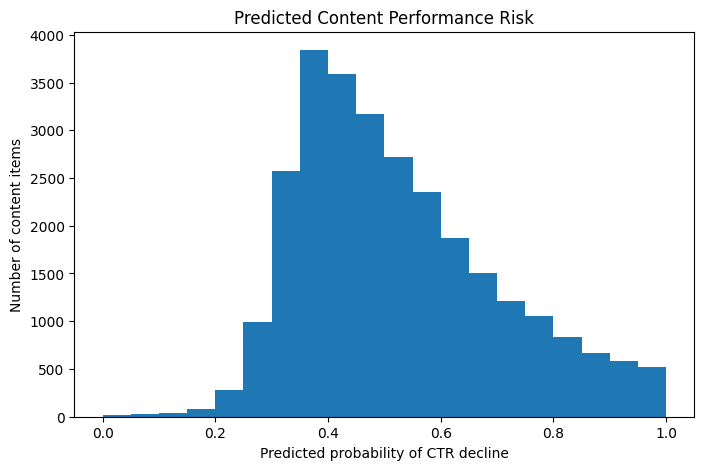

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results["risk_score"], bins=20)
plt.xlabel("Predicted probability of CTR decline")
plt.ylabel("Number of content items")
plt.title("Predicted Content Performance Risk")
plt.show()

## ML-12 — 5-Minute Demo

### 0:00–1:00 — Problem
Explain the goal: identify content that may experience weaker future performance using historical search and engagement signals.

### 1:00–2:00 — Data & Method
Show the historical feature window, future target window, selected features, and client-level train/test split.

### 2:00–3:00 — Model
Explain the Logistic Regression model and why standardized historical features were used.

### 3:00–4:00 — Results
Show ROC-AUC, Average Precision, confusion matrix, and the ranked content-risk output.

### 4:00–5:00 — Business Use
Explain how SEO/content teams can use the ranking to prioritize pages for human review and content refresh.

## Social Post

Built a content-performance ML workflow during my FlyRank AI internship.

I used historical SEO and engagement signals to identify content with a higher likelihood of future CTR decline, using a client-level holdout to reduce leakage.

The output is a ranked, decision-support list that can help content teams prioritize pages for review and optimization.

#MachineLearning #DataScience #SEO #AI #Internship

## Employer-Facing Summary

Built an end-to-end machine learning workflow to identify content at risk of weaker future CTR using historical SEO and engagement signals. Used client-level validation and Logistic Regression to produce measurable performance metrics and a ranked decision-support output. The project demonstrates practical skills in data engineering, feature engineering, leakage-aware validation, model evaluation, and business-oriented recommendations.

In [33]:
print("✅ CAPSTONE FINAL CHECK")
print("Features:", features.shape)
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Average Precision:", round(average_precision_score(y_test, proba), 3))
print("Top recommendations:", len(results))

✅ CAPSTONE FINAL CHECK
Features: (92353, 19)
Train: (64428, 12)
Test: (27925, 12)
ROC-AUC: 0.708
Average Precision: 0.618
Top recommendations: 27925


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
